In [43]:
import torch
import torchvision
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
image_2 = np.array(Image.open('photo/7f7e9290188a93d1084a3592f73ae889.png').convert('RGB'))
template = image_2[510:600, 0:225].copy()

model = torchvision.models.resnet18(pretrained=True)
layer4_features = None
avgpool_emb = None

def get_features(module, inputs, output):
    global layer4_features
    layer4_features = output

def get_embedding(module, inputs, output):
    global avgpool_emb
    avgpool_emb = output

model.layer4.register_forward_hook(get_features)
model.avgpool.register_forward_hook(get_embedding)
model.eval()

preprocess = torchvision.transforms.Compose([torchvision.transforms.ToPILImage(), torchvision.transforms.ToTensor(), torchvision.transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225])])

In [ ]:
# карта шаблонов
with torch.no_grad():
    input_tensor = preprocess(template)
    model(input_tensor[None, :, :, :])
    template_features = avgpool_emb.clone()

# карта признаков
with torch.no_grad():
    input_tensor = preprocess(image_2)
    model(input_tensor[None, :, :, :])
    image_features = layer4_features.clone() # [1, 512, H, W]

image_features = image_features.squeeze() # [512, H, W]
template_features = template_features.squeeze() # [512]

C, H, W = image_features.shape
image_features = image_features.view(C, -1)

template_features = F.normalize(template_features, dim=0)
image_features  = F.normalize(image_features, dim=0)

heat_map = template_features @ image_features
heat_map = heat_map.view(H, W)


heat_np = heat_map.cpu().detach().numpy()
heat_np = (heat_np - heat_np.min()) / (heat_np.max() - heat_np.min())

heat_pil = Image.fromarray((heat_np * 255).astype(np.uint8))
heat_resized = np.array(
    heat_pil.resize((image_2.shape[1], image_2.shape[0]), Image.BILINEAR)) / 255.0  

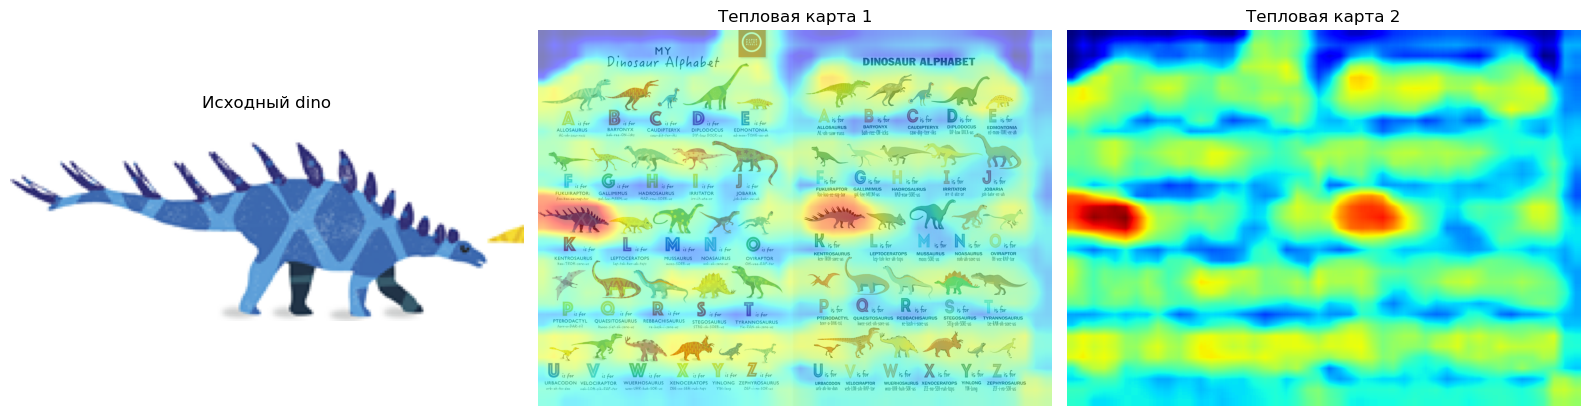

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(template)
axes[0].set_title("Исходный dino")
axes[0].axis('off')

axes[1].imshow(image_2)
axes[1].imshow(heat_resized, cmap='jet', alpha=0.5)
axes[1].set_title("Тепловая карта 1")
axes[1].axis('off')

axes[2].imshow(heat_resized, cmap='jet')
axes[2].set_title("Тепловая карта 2")
axes[2].axis('off')

plt.tight_layout()
plt.show()

y_max, x_max = np.unravel_index(np.argmax(heat_resized), heat_resized.shape)